In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import files
uploaded = files.upload()

Saving canada_per_capita_income (1).csv to canada_per_capita_income (1).csv


In [3]:
df = pd.read_csv("/content/canada_per_capita_income (1).csv")
df.head()

,year,per capita income (US$)
0,1970,3399.299037
1,1971,3768.297935
2,1972,4251.175484
3,1973,4804.463248
4,1974,5576.514583


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Define features (X) and target (y)
X = df[['year']]
y = df['per capita income (US$)']

# Split the data into training and testing sets (e.g., 80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

Training set size: 37 samples
Testing set size: 10 samples


In [5]:
# Initialize and train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Display the model's intercept and coefficient
print(f"Model Intercept: {model.intercept_:.2f}")
print(f"Model Coefficient (year): {model.coef_[0]:.2f}")

Model Intercept: -1605560.20
Model Coefficient (year): 815.14


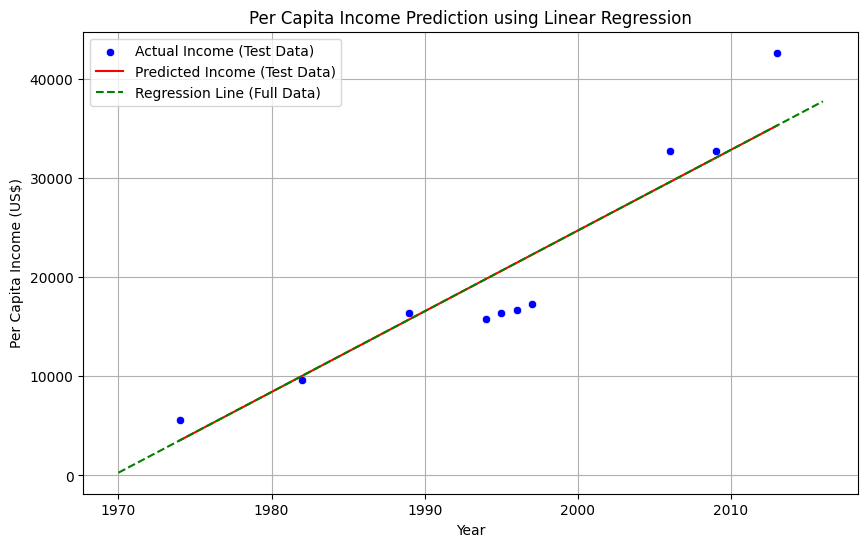

In [6]:
# Make predictions on the test set
y_pred = model.predict(X_test)

# Plot the actual vs. predicted values
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_test['year'], y=y_test, color='blue', label='Actual Income (Test Data)')
sns.lineplot(x=X_test['year'], y=y_pred, color='red', label='Predicted Income (Test Data)')

# Plot the full regression line using the entire dataset to show the overall trend
sns.lineplot(x=df['year'], y=model.predict(df[['year']]), color='green', linestyle='--', label='Regression Line (Full Data)')

plt.title('Per Capita Income Prediction using Linear Regression')
plt.xlabel('Year')
plt.ylabel('Per Capita Income (US$)')
plt.legend()
plt.grid(True)
plt.show()

In [7]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Evaluate the model's performance on the test set
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

Mean Absolute Error (MAE): 3240.91
Mean Squared Error (MSE): 15147815.55
Root Mean Squared Error (RMSE): 3892.02
R-squared (R2): 0.88


In [8]:
# Predict income for the year 1995
year_to_predict = pd.DataFrame([1995], columns=['year'])
predicted_income = model.predict(year_to_predict)

print(f"The predicted per capita income for the year 1995 is: ${predicted_income[0]:.2f}")

The predicted per capita income for the year 1995 is: $20649.11
